In [8]:
# !pip install pyreadstat
# !pip install numpy
# !pip install tensorflow
# !pip install pyreadstat
# !pip install tensorflow.python

### Ensuring reproducibility

In [9]:
import os
import random
import numpy as np
import tensorflow as tf

def set_seed(seed=42):
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['PYTHONHASHSEED'] = str(seed)         # Python hash seed
    random.seed(seed)                                # Python random module
    np.random.seed(seed)                             # NumPy
    tf.random.set_seed(seed)                         # TensorFlow
    tf.keras.utils.set_random_seed(seed)             # For keras randomness
    tf.config.experimental.enable_op_determinism()   # Make ops deterministic

# Call this before training
set_seed(42)


### Libraries

In [10]:
import pyreadstat
from sklearn.preprocessing import StandardScaler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, average_precision_score, PrecisionRecallDisplay, precision_recall_curve
from imblearn.over_sampling import SMOTE
from collections import Counter
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import Recall
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
import keras_tuner as kt
from tensorflow.keras import regularizers
from tensorflow.keras.metrics import Recall
from keras_tuner import HyperModel, RandomSearch
import shap

## Load data

In [11]:
df_ch = pyreadstat.read_sav(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.sav")[0]      #Local dataset
# Renaming the columns
feature_coded = df_ch[['AN4', 'AN8', 'BD2', 'CA1', 'CA14', 'HH6', 'HL4', 'melevel1', 'cinsurance', 'HH7c', 'windex5', 'WAZ2', 'HAZ2', 'WHZ2']]
df1 = feature_coded.rename(columns={
    'AN4': 'child_age',
    'AN8': 'child_weight',
    'BD2': 'ever_breastfed',
    'CA1': 'diarrhoea_last_2_weeks',
    'CA14': 'fever_last_2_weeks',
    'HH6': 'area',
    'HL4': 'child_sex',
    'melevel1': 'mother_education',
    'cinsurance': 'health_insurance',
    'HH7c': 'province',
    'windex5': 'wealth_index',
    'WAZ2': 'underweight',
    'HAZ2': 'stunting',
    'WHZ2': 'wasting'
})

# Remove rows with coded entries in each column
coded_child_age = [99.6, 99.5, 99.4, 99.3]
coded_underweight = [99.99, 99.98, 99.97]
coded_stunting = [99.99, 99.98, 99.97]
coded_wasting = [99.97]
coded_diarrhoea = [9, 8]
coded_fever = [8]
coded_insurance = [9]
coded_breastfed = [9]

df1 = df1[~df1['child_age'].isin(coded_child_age)]
df1 = df1[~df1['underweight'].isin(coded_underweight)]
df1 = df1[~df1['stunting'].isin(coded_stunting)]
df1 = df1[~df1['wasting'].isin(coded_wasting)] 
df1 = df1[~df1['diarrhoea_last_2_weeks'].isin(coded_diarrhoea)]
df1 = df1[~df1['fever_last_2_weeks'].isin(coded_fever)]
df1 = df1[~df1['health_insurance'].isin(coded_insurance)]
df1 = df1[~df1['ever_breastfed'].isin(coded_breastfed)]

# Convert to Binary Response Variables
df2 = df1.copy()
df2['underweight'] = [0 if -2 <= x < 2 else 1 for x in df2['underweight']]
df2['stunting'] = [0 if -2 <= x < 2 else 1 for x in df2['stunting']]
df2['wasting'] = [0 if -2 <= x < 2 else 1 for x in df2['wasting']]

# Change binary features from 1/2 to 1/0
df2[['ever_breastfed', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'health_insurance']] = df2[['ever_breastfed', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'health_insurance']].replace({2: 0})

df2['malnurished'] = df2[['underweight', 'stunting', 'wasting']].apply(lambda x: 1 if any(i == 1 for i in x) else 0, axis=1)
df3 = df2.drop(['underweight', 'stunting', 'wasting'], axis=1)

# Standardize childe weight
scaler = StandardScaler()
df3['child_weight'] = scaler.fit_transform(df3[['child_weight']])

df4 = df3.drop(columns=['ever_breastfed'])

# Drop missing values and make a copy to avoid chained assignment issues
df = df4.dropna().copy()

# Convert all columns except 'child_weight' to integer
cols_to_convert = df.columns.difference(['child_weight'])
df[cols_to_convert] = df[cols_to_convert].astype(int)

df.head(2)

,child_age,child_weight,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,province,wealth_index,malnurished
0,1,-1.085628,0,0,0,1,5,0,1,1,1
1,3,0.420314,0,1,0,1,5,0,1,1,1


In [12]:
df['wealth_index'] -= 1
df['province'] -= 1
edu_map = {0: 0, 2: 1, 5: 2, 8: 3, 9: 4}
df['mother_education'] = df['mother_education'].map(edu_map)


In [14]:
df['mother_education'].value_counts()

mother_education
2    2345
1    2031
0    1571
3     480
4       3
Name: count, dtype: int64

### Train-test Split

In [15]:
X = df.drop(columns=['malnurished'])
y = df['malnurished']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# We want 15% of total data as validation, which is 15 / 80 = 0.1875 of the temp set
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1875, stratify=y_temp, random_state=42)

In [24]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Flatten, Concatenate, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import Recall

# 1. Define input layers for categorical features
cat_inputs = {
    'child_age': Input(shape=(1,), name='child_age'),
    'mother_education': Input(shape=(1,), name='mother_education'),
    'wealth_index': Input(shape=(1,), name='wealth_index'),
    'province': Input(shape=(1,), name='province')
}

# 2. Embedding dimensions (rule of thumb: min(50, (n_cat + 1)//2))
embedding_sizes = {
    'child_age': (5, 3),
    'mother_education': (5, 3),
    'wealth_index': (5, 3),
    'province': (7, 4)
}

# 3. Create embedding layers
embedded_layers = []
for feature_name, input_layer in cat_inputs.items():
    vocab_size, emb_dim = embedding_sizes[feature_name]
    emb = Embedding(input_dim=vocab_size, output_dim=emb_dim, name=f'emb_{feature_name}')(input_layer)
    embedded_layers.append(Flatten()(emb))

# 4. Input for binary + continuous features
cont_input = Input(shape=(6,), name='cont_inputs')  # 5 binary + 1 continuous (child_weight)

# 5. Concatenate everything
x = Concatenate()(embedded_layers + [cont_input])

# 6. Fully connected layers
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(32, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(1, activation='sigmoid')(x)

# 7. Build model
model = Model(inputs=[*cat_inputs.values(), cont_input], outputs=output)

# 8. Compile
model.compile(
    optimizer=Adam(learning_rate=0.005),
    loss='binary_crossentropy',
    metrics=['accuracy', Recall(name='recall')]
)

# 9. Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


In [25]:
X_train_input = {
    'child_age': X_train['child_age'].values,
    'mother_education': X_train['mother_education'].values,
    'wealth_index': X_train['wealth_index'].values,
    'province': X_train['province'].values,
    'cont_inputs': X_train[[
        'diarrhoea_last_2_weeks',
        'fever_last_2_weeks',
        'area',
        'child_sex',
        'health_insurance',
        'child_weight'
    ]].values
}

X_val_input = {
    'child_age': X_val['child_age'].values,
    'mother_education': X_val['mother_education'].values,
    'wealth_index': X_val['wealth_index'].values,
    'province': X_val['province'].values,
    'cont_inputs': X_val[[
        'diarrhoea_last_2_weeks',
        'fever_last_2_weeks',
        'area',
        'child_sex',
        'health_insurance',
        'child_weight'
    ]].values
}


In [26]:
history = model.fit(
    X_train_input, y_train,
    validation_data=(X_val_input, y_val),
    epochs=100,
    batch_size=16,
    shuffle=True,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
262/262 [==============================] - 3s 4ms/step - loss: 0.5982 - accuracy: 0.6760 - recall: 0.5510 - val_loss: 0.5244 - val_accuracy: 0.7554 - val_recall: 0.6728
Epoch 2/100
262/262 [==============================] - 1s 3ms/step - loss: 0.5316 - accuracy: 0.7447 - recall: 0.6196 - val_loss: 0.5058 - val_accuracy: 0.7606 - val_recall: 0.6452
Epoch 3/100
262/262 [==============================] - 1s 3ms/step - loss: 0.5290 - accuracy: 0.7423 - recall: 0.5972 - val_loss: 0.5270 - val_accuracy: 0.7378 - val_recall: 0.5553
Epoch 4/100
262/262 [==============================] - 1s 3ms/step - loss: 0.5251 - accuracy: 0.7444 - recall: 0.6057 - val_loss: 0.5092 - val_accuracy: 0.7472 - val_recall: 0.6244
Epoch 5/100
262/262 [==============================] - 1s 3ms/step - loss: 0.5134 - accuracy: 0.7454 - recall: 0.5956 - val_loss: 0.5109 - val_accuracy: 0.7358 - val_recall: 0.5392
Epoch 6/100
262/262 [==============================] - 1s 3ms/step - loss: 0.5146 - accuracy: 0

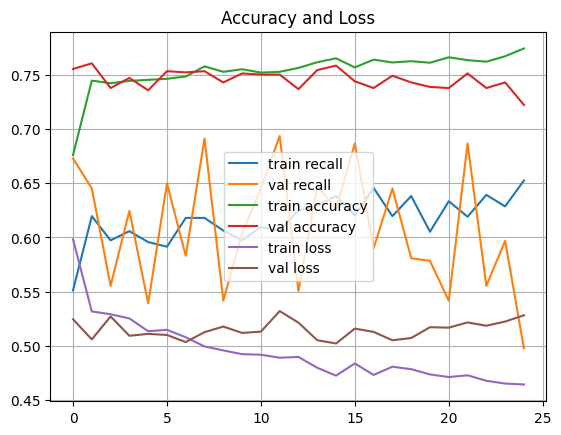

In [27]:
# Accuracies and losses
plt.plot(history.history['recall'], label='train recall')
plt.plot(history.history['val_recall'], label='val recall')
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.grid()
plt.title('Accuracy and Loss')
plt.show()

In [28]:
X_test_input = {
    'child_age': X_test['child_age'].values,
    'mother_education': X_test['mother_education'].values,
    'wealth_index': X_test['wealth_index'].values,
    'province': X_test['province'].values,
    'cont_inputs': X_test[[
        'diarrhoea_last_2_weeks',
        'fever_last_2_weeks',
        'area',
        'child_sex',
        'health_insurance',
        'child_weight'
    ]].values
}

In [29]:
# Predict probabilities
y_test_prob = model.predict(X_test_input)

# Convert to binary predictions
y_test_pred = (y_test_prob >= 0.5).astype(int)
print(classification_report(y_test, y_test_pred))


41/41 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0       0.74      0.85      0.79       707
           1       0.77      0.63      0.69       579

    accuracy                           0.75      1286
   macro avg       0.76      0.74      0.74      1286
weighted avg       0.75      0.75      0.75      1286



In [22]:
# Compute Average Precision Score
print(f'Average Precision: {average_precision_score(y_test, y_test_pred)}')

Average Precision: 0.6546029006967278


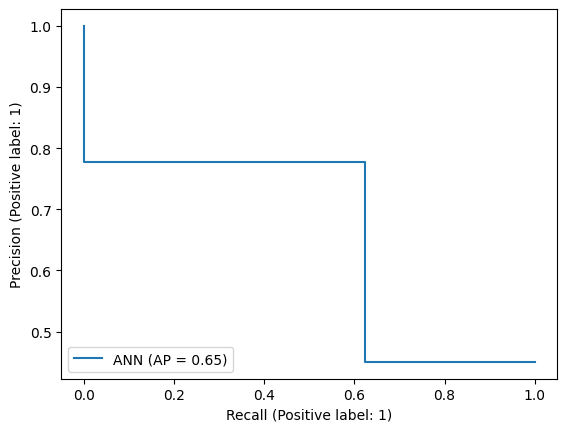

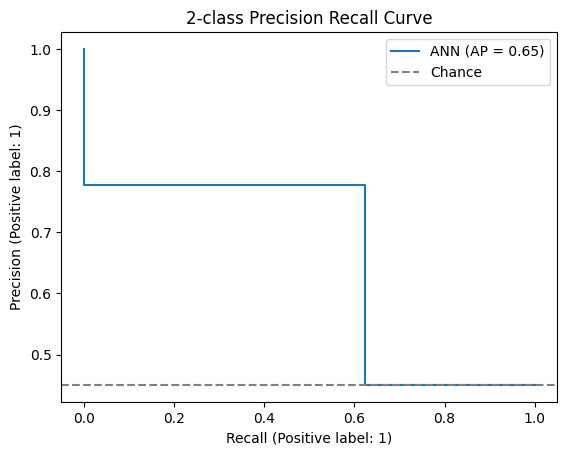

In [23]:
# Plot using from_predictions
display = PrecisionRecallDisplay.from_predictions(
    y_test,
    y_test_pred,
    name="ANN"
)
display.plot()
plt.axhline(y=sum(y_test) / len(y_test), color='gray', linestyle='--', label='Chance')
plt.title('2-class Precision Recall Curve')
plt.legend()
plt.show()